## SCC

In [14]:
import scanpy as sc
adata_ST1=sc.read_h5ad('/home/qyyuan/project/ST_GRN/TESLA/tutorial/results/enhanced_exp.h5ad')
adata_ST_Ori=sc.read('/home/qyyuan/project/ST_GRN/data/SCC/adata_SCC_ST.h5ad')

/home/qyyuan/.conda/envs/STALocator-zzqyy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/qyyuan/.conda/envs/STALocator-zzqyy/lib/python3.9/site-packages/anndata/__init__.py:55: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [ ]:
points1=adata_ST_Ori.obs[['pixel_x','pixel_y']].to_numpy()
df=adata_ST_Ori.obs[['pixel_x','pixel_y']]

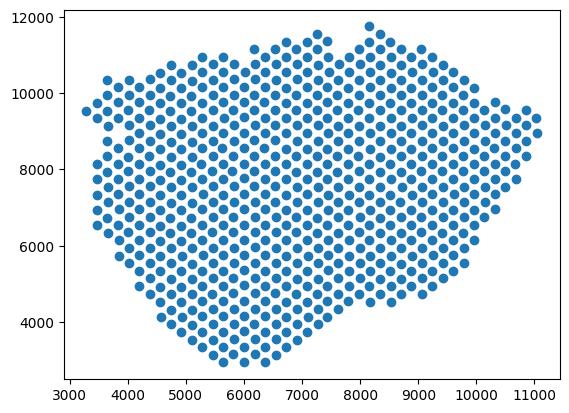

In [18]:
import matplotlib.pyplot as plt
plt.scatter(df['pixel_x'], df['pixel_y'])
plt.show()

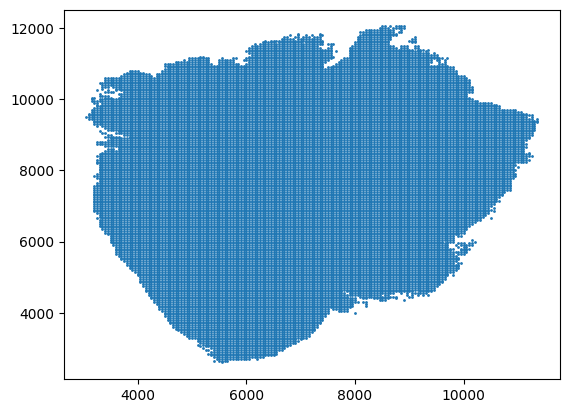

In [21]:
points2=adata_ST1.obs[['y','x']].to_numpy()
df=adata_ST1.obs[['x','y']]
import matplotlib.pyplot as plt
plt.scatter(df['y'], df['x'], s=1)
plt.show()

In [22]:
import numpy as np
import matplotlib.pyplot as plt
def find_nearest_rows_vectorized(points1, points2):
    """
    向量化版本的最近邻搜索，效率更高
    """
    if points1.shape[1] != 2 or points2.shape[1] != 2:
        raise ValueError("两个矩阵都必须是N*2的形状")
    # 使用广播计算所有点对之间的距离
    # 扩展维度以便广播计算
    points1_expanded = points1[:, np.newaxis, :]  # 形状: (N, 1, 2)
    points2_expanded = points2[np.newaxis, :, :]  # 形状: (1, M, 2)
    # 计算平方距离（避免开方计算，因为argmin结果相同）
    squared_distances = np.sum((points1_expanded - points2_expanded) ** 2, axis=2)  
    # 找到每个点在points2中的最近邻索引
    nearest_indices = np.argmin(squared_distances, axis=1)
    # 计算最小距离
    nearest_distances = np.sqrt(np.min(squared_distances, axis=1))
    return nearest_indices, nearest_distances

# 示例数据

# 调用函数获取最近邻和最近距离
nearest_indices, nearest_distances = find_nearest_rows_vectorized(points1, points2)



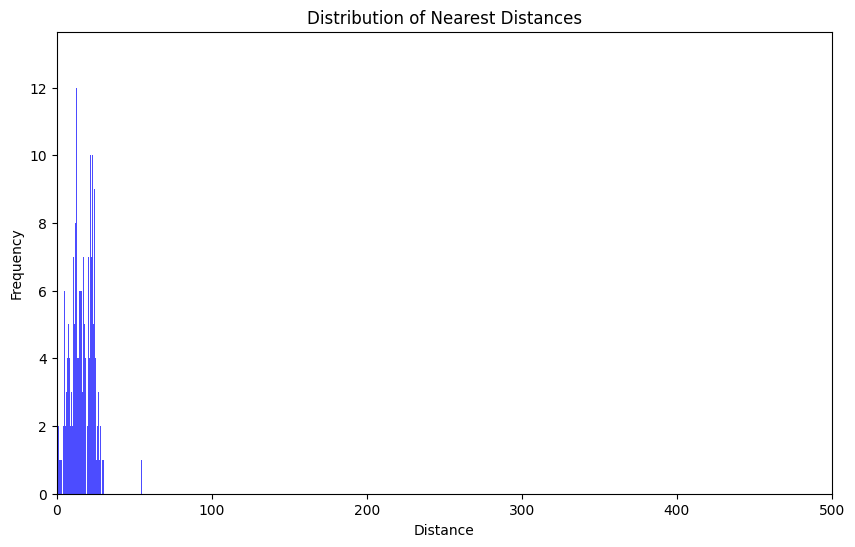

In [23]:
# 绘制最近距离的分布
plt.figure(figsize=(10, 6))
plt.hist(nearest_distances, bins=300, color='blue', alpha=0.7)
plt.title('Distribution of Nearest Distances')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.xlim(0, 500)
plt.show()

In [24]:
import pandas as pd
mapping_mouse=pd.DataFrame(nearest_indices)
mapping_mouse.columns=['target_index']
mapping_mouse['dist']=nearest_distances
mapping_mouse['ori_index']=[i for i in range(len(nearest_indices))]
mapping_mouse.to_csv('/home/qyyuan/project/ST_GRN/TESLA/tutorial/results/mapping_SCC.txt',sep='\t')

### mapping 6 cluster

In [22]:
import pandas as pd

# 读取文件
# 完整的表格文件
full_table_path = "/home/zzhang/SPADE/SpaGCN/tutorial/sample_results/scc_domian_6.txt"
# 包含target_index的文件

# 读取数据
full_df = pd.read_csv(full_table_path, sep='\t',index_col=0)  # 如果是制表符分隔

In [11]:
import scanpy as sc
adata_ST_Ori=sc.read('/home/qyyuan/project/ST_GRN/data/SCC/adata_SCC_ST.h5ad')
points1=adata_ST_Ori.obs[['pixel_x','pixel_y']].to_numpy()
df=adata_ST_Ori.obs[['pixel_x','pixel_y']]

/home/qyyuan/.conda/envs/STALocator-zzqyy/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/qyyuan/.conda/envs/STALocator-zzqyy/lib/python3.9/site-packages/anndata/__init__.py:55: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


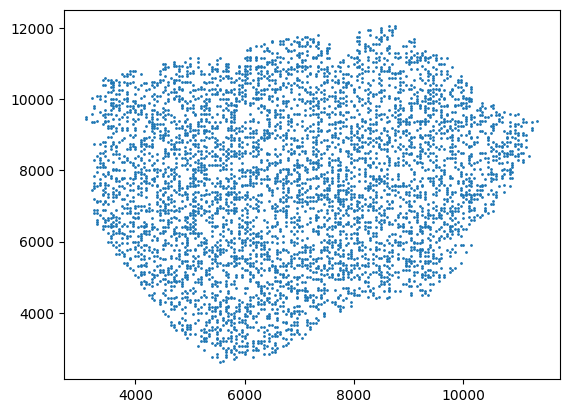

In [14]:
points2=full_df[['y','x']].to_numpy()
df=full_df[['x','y']]
import matplotlib.pyplot as plt
plt.scatter(df['y'], df['x'], s=1)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def find_nearest_rows_vectorized(points1, points2):
    """
    向量化版本的最近邻搜索，效率更高
    """
    if points1.shape[1] != 2 or points2.shape[1] != 2:
        raise ValueError("两个矩阵都必须是N*2的形状")
    # 使用广播计算所有点对之间的距离
    # 扩展维度以便广播计算
    points1_expanded = points1[:, np.newaxis, :]  # 形状: (N, 1, 2)
    points2_expanded = points2[np.newaxis, :, :]  # 形状: (1, M, 2)
    # 计算平方距离（避免开方计算，因为argmin结果相同）
    squared_distances = np.sum((points1_expanded - points2_expanded) ** 2, axis=2)  
    # 找到每个点在points2中的最近邻索引
    nearest_indices = np.argmin(squared_distances, axis=1)
    # 计算最小距离
    nearest_distances = np.sqrt(np.min(squared_distances, axis=1))
    return nearest_indices, nearest_distances

# 示例数据

# 调用函数获取最近邻和最近距离
nearest_indices, nearest_distances = find_nearest_rows_vectorized(points1, points2)
full_df=full_df.reset_index()


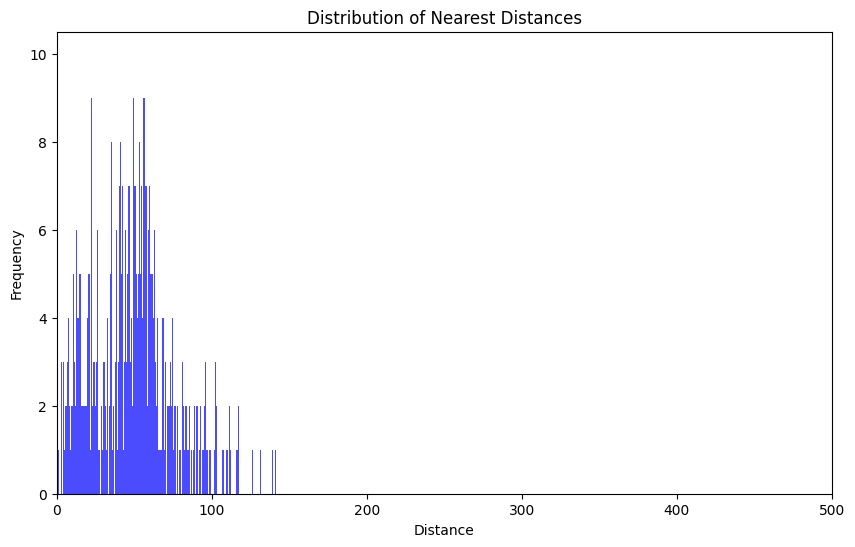

In [16]:
# 绘制最近距离的分布
plt.figure(figsize=(10, 6))
plt.hist(nearest_distances, bins=300, color='blue', alpha=0.7)
plt.title('Distribution of Nearest Distances')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.xlim(0, 500)
plt.show()

In [ ]:
import pandas as pd
mapping_mouse=pd.DataFrame(nearest_indices)
mapping_mouse.columns=['target_index']
mapping_mouse['dist']=nearest_distances
mapping_mouse['ori_index']=[i for i in range(len(nearest_indices))]
extracted_rows = full_df.iloc[nearest_indices].reset_index(drop=True)
merged_df = pd.concat([mapping_mouse, extracted_rows], axis=1)
merged_df.to_csv('/home/qyyuan/project/ST_GRN/TESLA/tutorial/results/mapping_SCC_cluster6.txt',sep='\t')

## Mouse Brain

In [25]:
import scanpy as sc
adata_ST1=sc.read_h5ad('/home/qyyuan/project/ST_GRN/TESLA/tutorial/results/enhanced_exp1.h5ad')
adata_ST_Ori=sc.read('/home/qyyuan/project/ST_GRN/data/mouse_anterior/adata_ST.h5ad')

/home/qyyuan/.conda/envs/STALocator-zzqyy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/qyyuan/.conda/envs/STALocator-zzqyy/lib/python3.9/site-packages/anndata/__init__.py:55: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(
/home/qyyuan/.conda/envs/STALocator-zzqyy/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [ ]:
points1=adata_ST_Ori.obs[['pixel_x','pixel_y']].to_numpy()
df=adata_ST_Ori.obs[['pixel_x','pixel_y']]

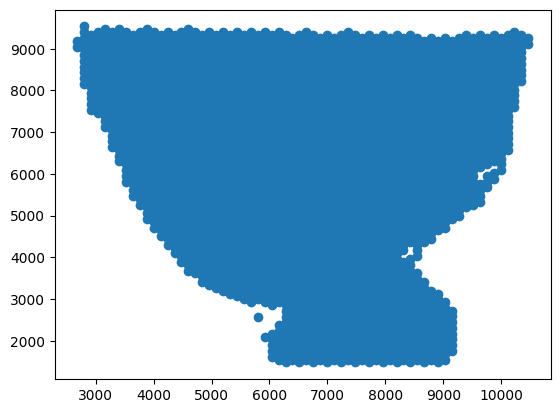

In [4]:
import matplotlib.pyplot as plt
plt.scatter(df['pixel_x'], df['pixel_y'])
plt.show()

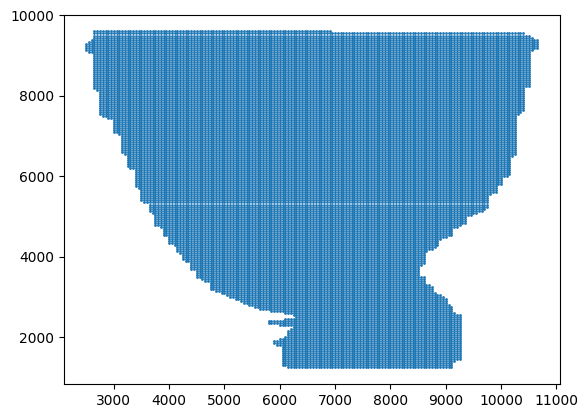

In [ ]:
points2=adata_ST1.obs[['x','y']].to_numpy()
df=adata_ST1.obs[['x','y']]
import matplotlib.pyplot as plt
plt.scatter(df['x'], df['y'], s=1)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def find_nearest_rows_vectorized(points1, points2):
    """
    向量化版本的最近邻搜索，效率更高
    """
    if points1.shape[1] != 2 or points2.shape[1] != 2:
        raise ValueError("两个矩阵都必须是N*2的形状")
    # 使用广播计算所有点对之间的距离
    # 扩展维度以便广播计算
    points1_expanded = points1[:, np.newaxis, :]  # 形状: (N, 1, 2)
    points2_expanded = points2[np.newaxis, :, :]  # 形状: (1, M, 2)
    # 计算平方距离（避免开方计算，因为argmin结果相同）
    squared_distances = np.sum((points1_expanded - points2_expanded) ** 2, axis=2)  
    # 找到每个点在points2中的最近邻索引
    nearest_indices = np.argmin(squared_distances, axis=1)
    # 计算最小距离
    nearest_distances = np.sqrt(np.min(squared_distances, axis=1))
    return nearest_indices, nearest_distances

# 示例数据
# 调用函数获取最近邻和最近距离
nearest_indices, nearest_distances = find_nearest_rows_vectorized(points1, points2)

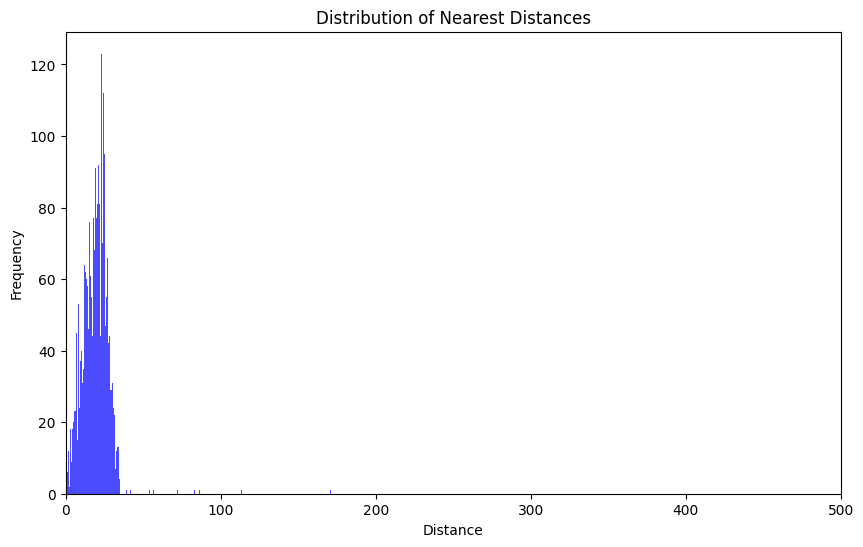

In [9]:
# 绘制最近距离的分布
plt.figure(figsize=(10, 6))
plt.hist(nearest_distances, bins=300, color='blue', alpha=0.7)
plt.title('Distribution of Nearest Distances')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.xlim(0, 500)
plt.show()

In [11]:
import pandas as pd
mapping_mouse=pd.DataFrame(nearest_indices)
mapping_mouse.columns=['target_index']
mapping_mouse['dist']=nearest_distances
mapping_mouse['ori_index']=[i for i in range(len(nearest_indices))]

In [12]:
mapping_mouse.to_csv('/home/qyyuan/project/ST_GRN/TESLA/tutorial/results/mapping_mouse.txt',sep='\t')

## PDAC

In [42]:
import scanpy as sc
adata_ST1=sc.read_h5ad('/home/qyyuan/project/ST_GRN/TESLA/tutorial/results/enhanced_exp_PDAC.h5ad')
adata_ST_Ori=sc.read('/home/qyyuan/project/ST_GRN/data/PDAC/adata_PDAC_ST.h5ad')
adata_ST_Ori.obs[['pixel_x','pixel_y']] = adata_ST_Ori.obsm['spatial']*200
adata_ST_Ori.obs['pixel_x'] = 7500 - adata_ST_Ori.obs['pixel_x']
adata_ST_Ori.obs['pixel_y'] = 1000 + adata_ST_Ori.obs['pixel_y']

/home/qyyuan/.conda/envs/STALocator-zzqyy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/qyyuan/.conda/envs/STALocator-zzqyy/lib/python3.9/site-packages/anndata/__init__.py:55: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [43]:
points1=adata_ST_Ori.obs[['pixel_x','pixel_y']].to_numpy()
df=adata_ST_Ori.obs[['pixel_x','pixel_y']]

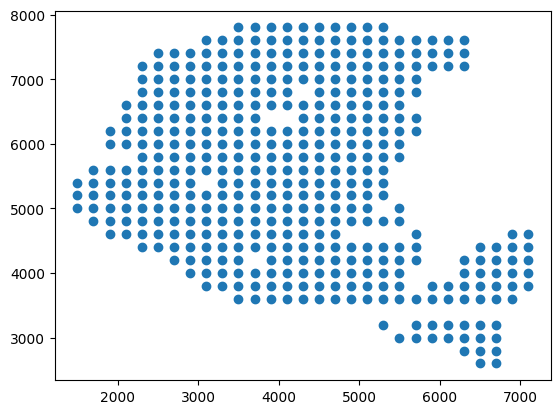

In [44]:
import matplotlib.pyplot as plt
plt.scatter(df['pixel_x'], df['pixel_y'])
plt.show()

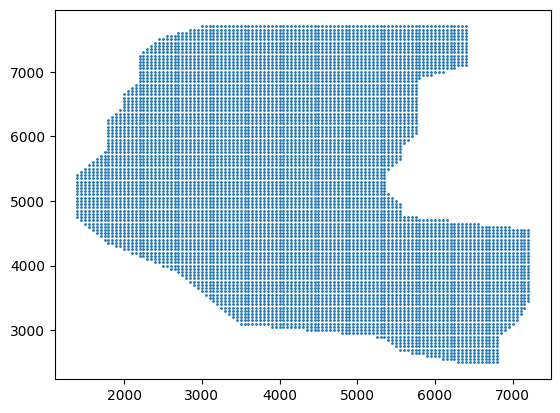

In [45]:
points2=adata_ST1.obs[['x','y']].to_numpy()
df=adata_ST1.obs[['x','y']]
import matplotlib.pyplot as plt
plt.scatter(df['x'], df['y'], s=1)
plt.show()

In [49]:
nearest_indices, nearest_distances = find_nearest_rows_vectorized(points1, points2)

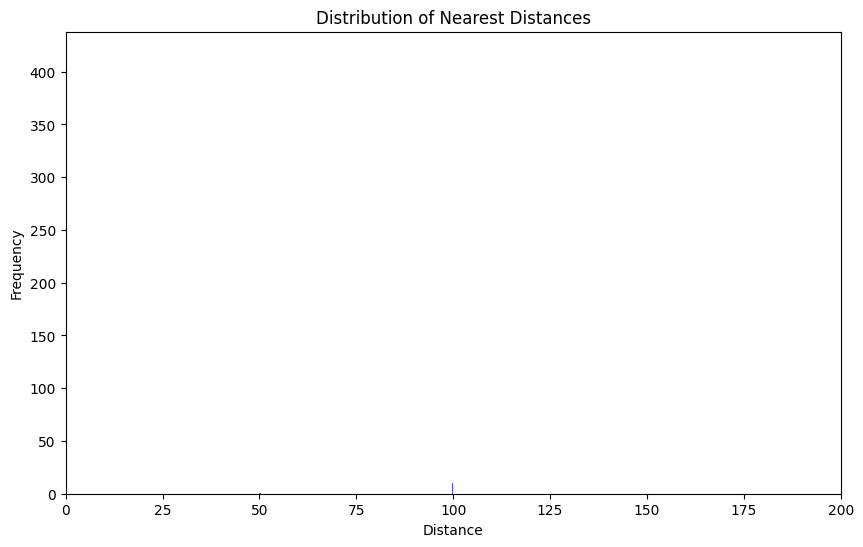

In [51]:
# 绘制最近距离的分布
plt.figure(figsize=(10, 6))
plt.hist(nearest_distances, bins=300, color='blue', alpha=0.7)
plt.title('Distribution of Nearest Distances')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.xlim(0, 200)
plt.show()

In [52]:
import pandas as pd
mapping_mouse=pd.DataFrame(nearest_indices)
mapping_mouse.columns=['target_index']
mapping_mouse['dist']=nearest_distances
mapping_mouse['ori_index']=[i for i in range(len(nearest_indices))]

In [53]:
mapping_mouse.to_csv('/home/qyyuan/project/ST_GRN/TESLA/tutorial/results/mapping_PDAC.txt',sep='\t')

In [4]:

mapping_df = pd.read_csv(mapping_path, sep='\t')   # 如果是制表符分隔

# 显示数据基本信息，确认读取正确
print("完整表格形状:", full_df.shape)
print("完整表格列名:", full_df.columns.tolist())
print("\n映射表格形状:", mapping_df.shape)
print("映射表格列名:", mapping_df.columns.tolist())



完整表格形状: (5000, 12)
完整表格列名: ['x', 'y', 'color', 'z', 'CD151', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'n_counts', 'pred', 'refined_pred']

映射表格形状: (666, 4)
映射表格列名: ['Unnamed: 0', 'target_index', 'dist', 'ori_index']


In [8]:
full_df

,x,y,color,z,CD151,x_array,y_array,x_pixel,y_pixel,n_counts,pred,refined_pred
7760,6850,7350,157.660893,-1001.645198,1.212193,6850,7350,6850,7350,5133.8594,0,0
5157,5900,5700,131.433166,-2383.178557,0.907866,5900,5700,5900,5700,4711.6514,1,1
10818,7850,9600,182.462336,304.759343,0.654688,7850,9600,7850,9600,2007.3618,3,3
7738,6850,6250,134.480439,-2222.664836,0.205531,6850,6250,6850,6250,2695.2654,2,2
15310,9300,8050,186.386338,511.454345,0.311305,9300,8050,9300,8050,1395.5230,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
13155,8600,9650,164.143737,-660.164354,0.342248,8600,9650,8600,9650,972.3794,7,7
9862,7550,7700,180.115877,181.160709,0.941928,7550,7700,7550,7700,4508.4395,0,0
9158,7300,10600,232.614696,2946.511679,0.117630,7300,10600,7300,10600,600.8194,3,3
15328,9300,8950,203.163580,1395.187784,0.475869,9300,8950,9300,8950,1614.5852,0,0


In [6]:
# 根据target_index从完整表格中提取对应的行
# 假设完整表格的第一列是索引列

# 合并两个表格
# 横向合并，按行对应
merged_df = pd.concat([mapping_df, extracted_rows], axis=1)



IndexError: positional indexers are out-of-bounds

In [ ]:
# 保存结果
output_path = "./merged_results.txt"
merged_df.to_csv(output_path, sep='\t', index=False)

print(f"\n合并完成！结果已保存到: {output_path}")
print("合并后的表格形状:", merged_df.shape)
print("合并后的表格列名:", merged_df.columns.tolist())

# 显示前几行结果
print("\n合并结果的前5行:")
print(merged_df.head())

## Human Luminal B Breat cancer

In [75]:
import scanpy as sc
adata_ST1=sc.read_h5ad('/home/qyyuan/project/ST_GRN/result/Human_Luminal_B_Breast_cancer/enhanced_exp_BCAS1.h5ad')
#adata_ST_Ori=sc.read('/home/qyyuan/project/ST_GRN/data/mouse_anterior/adata_ST.h5ad')
adata_ST_Ori = sc.read_10x_h5("/home/qyyuan/project/ST_GRN/data/Human_Luminal_B_Breast_cancer/BCAS1/V1_Breast_Cancer_Block_A_Section_1_filtered_feature_bc_matrix.h5")
import pandas as pd
location0=pd.read_csv('/home/qyyuan/project/ST_GRN/result/Human_Luminal_B_Breast_cancer/BCAS1_doman_20.txt',sep='\t',index_col=0)

location=pd.read_csv('/home/qyyuan/project/ST_GRN/data/Human_Luminal_B_Breast_cancer/BCAS1/spatial/tissue_positions_list.csv',sep=',',header=None)
location=location.set_index(0)
location=location.loc[adata_ST_Ori.obs_names]
adata_ST_Ori.obs[['pixel_x',	'pixel_y']]=location[[5,4]]*0.08250825
points1=adata_ST_Ori.obs[['pixel_x','pixel_y']].to_numpy()
df=adata_ST_Ori.obs[['pixel_x','pixel_y']]

/home/qyyuan/.conda/envs/STALocator-zzqyy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/qyyuan/.conda/envs/STALocator-zzqyy/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/qyyuan/.conda/envs/STALocator-zzqyy/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


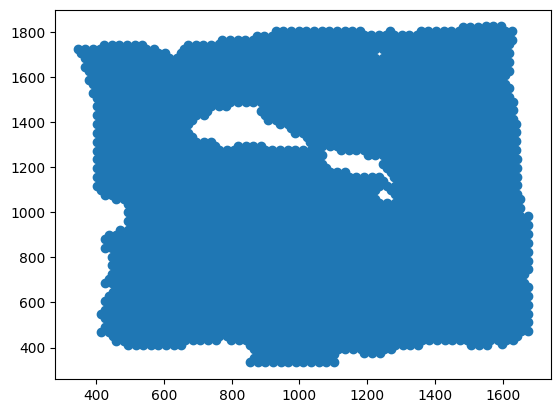

In [76]:
import matplotlib.pyplot as plt
plt.scatter(df['pixel_x'], df['pixel_y'])
plt.show()

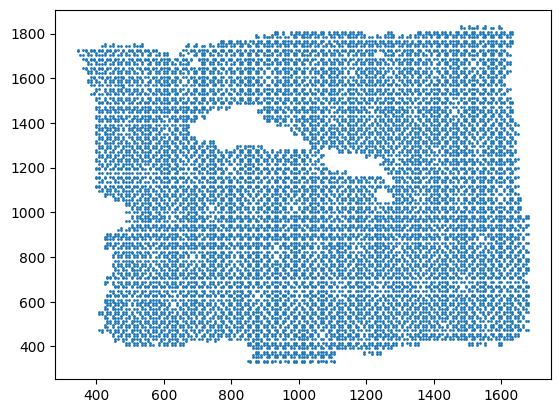

In [77]:
adata_ST1 = adata_ST1[location0.index,:]
points2=adata_ST1.obs[['y','x']].to_numpy()
df=adata_ST1.obs[['x','y']]
import matplotlib.pyplot as plt
plt.scatter(df['y'], df['x'], s=1)
plt.show()

In [78]:
import numpy as np
import matplotlib.pyplot as plt
def find_nearest_rows_vectorized(points1, points2):
    """
    向量化版本的最近邻搜索，效率更高
    """
    if points1.shape[1] != 2 or points2.shape[1] != 2:
        raise ValueError("两个矩阵都必须是N*2的形状")
    points1_expanded = points1[:, np.newaxis, :]  # 形状: (N, 1, 2)
    points2_expanded = points2[np.newaxis, :, :]  # 形状: (1, M, 2)
    squared_distances = np.sum((points1_expanded - points2_expanded) ** 2, axis=2)  
    nearest_indices = np.argmin(squared_distances, axis=1)
    nearest_distances = np.sqrt(np.min(squared_distances, axis=1))
    return nearest_indices, nearest_distances

nearest_indices, nearest_distances = find_nearest_rows_vectorized(points1, points2)
#full_df=full_df.reset_index()


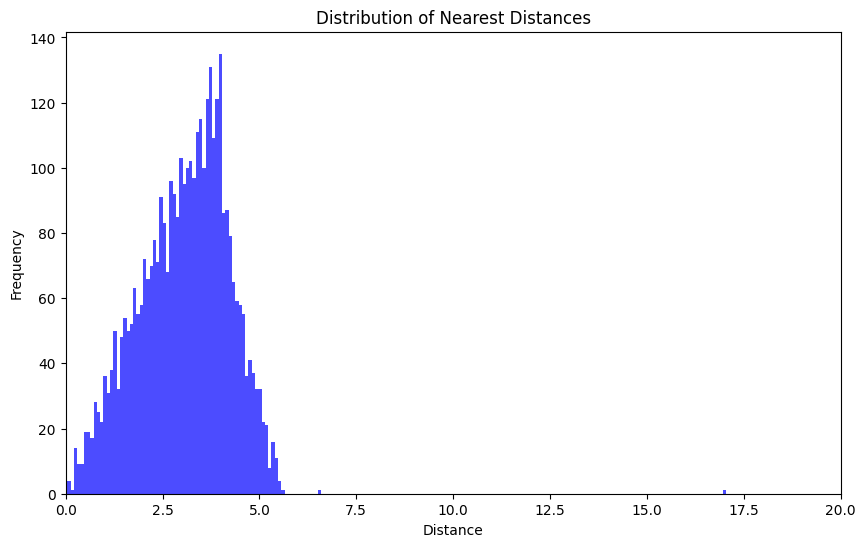

In [79]:
# 绘制最近距离的分布
plt.figure(figsize=(10, 6))
plt.hist(nearest_distances, bins=200, color='blue', alpha=0.7)
plt.title('Distribution of Nearest Distances')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.xlim(0, 20)
plt.show()

In [ ]:
import pandas as pd
mapping_mouse=pd.DataFrame(nearest_indices)
mapping_mouse.columns=['target_index']
mapping_mouse['dist']=nearest_distances
mapping_mouse['ori_index']=[i for i in range(len(nearest_indices))]
location0['index0']=[i for i in range(location0.shape[0])]
merge_df=pd.merge(left=mapping_mouse,right=location0.reset_index(),left_on='target_index',right_on='index0',how='inner')
merge_df=merge_df[merge_df['dist']<6]
merge_df.index=adata_ST_Ori.obs_names[merge_df['ori_index']]
merge_df.to_csv('/home/qyyuan/project/ST_GRN/result/Human_Luminal_B_Breast_cancer/mapping_BCAS1_v1.txt',sep='\t')

In [83]:
nearest_indices1, nearest_distances1 = find_nearest_rows_vectorized(points2, points1)

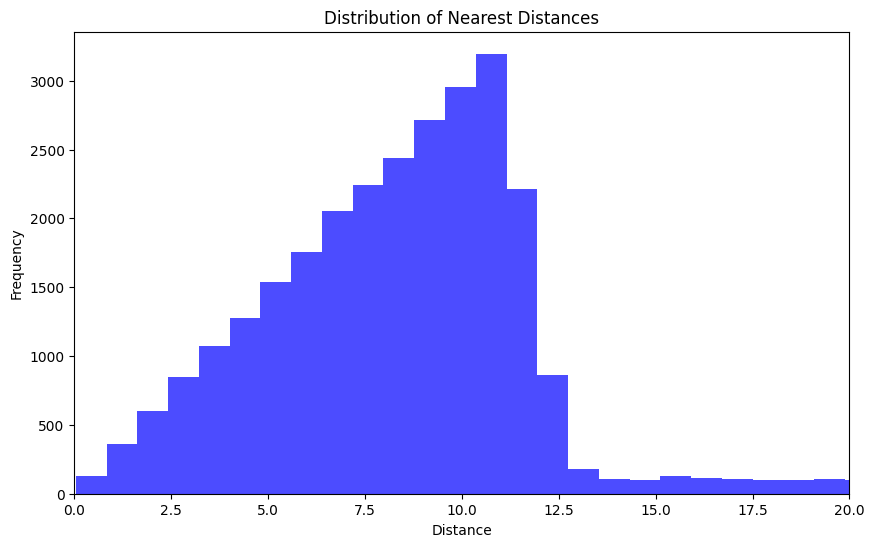

In [84]:
# 绘制最近距离的分布
plt.figure(figsize=(10, 6))
plt.hist(nearest_distances1, bins=300, color='blue', alpha=0.7)
plt.title('Distribution of Nearest Distances')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.xlim(0, 20)
plt.show()

In [ ]:
import pandas as pd
mapping_mouse=pd.DataFrame(nearest_indices1)
mapping_mouse.columns=['target_index']
mapping_mouse['dist']=nearest_distances1
mapping_mouse['ori_index']=[i for i in range(len(nearest_indices1))]
mapping_mouse=mapping_mouse[mapping_mouse['dist']<8]
mapping_mouse.to_csv('/home/qyyuan/project/ST_GRN/result/Human_Luminal_B_Breast_cancer/selected_spots_BCAS1.txt')

## Human Luminal B Breat cancer 2

In [ ]:
import scanpy as sc
adata_ST1=sc.read_h5ad('/home/qyyuan/project/ST_GRN/result/Human_Luminal_B_Breast_cancer/enhanced_exp_BCAS2.h5ad')
adata_ST_Ori = sc.read_10x_h5("/home/qyyuan/project/ST_GRN/data/Human_Luminal_B_Breast_cancer/BCAS2/V1_Breast_Cancer_Block_A_Section_2_filtered_feature_bc_matrix.h5")
import pandas as pd
location0=pd.read_csv('/home/qyyuan/project/ST_GRN/result/Human_Luminal_B_Breast_cancer/BCAS2_doman_8.txt',sep='\t',index_col=0)
location=pd.read_csv('/home/qyyuan/project/ST_GRN/data/Human_Luminal_B_Breast_cancer/BCAS2/spatial/tissue_positions_list.csv',sep=',',header=None)
location=location.set_index(0)
location=location.loc[adata_ST_Ori.obs_names]
adata_ST_Ori.obs[['pixel_x',	'pixel_y']]=location[[5,4]]*0.08250825
points1=adata_ST_Ori.obs[['pixel_x','pixel_y']].to_numpy()
df=adata_ST_Ori.obs[['pixel_x','pixel_y']]


/home/qyyuan/.conda/envs/STALocator-zzqyy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/qyyuan/.conda/envs/STALocator-zzqyy/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/qyyuan/.conda/envs/STALocator-zzqyy/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


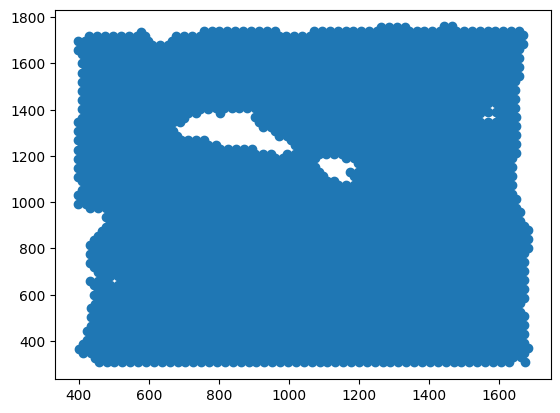

In [66]:
import matplotlib.pyplot as plt
plt.scatter(df['pixel_x'], df['pixel_y'])
plt.show()

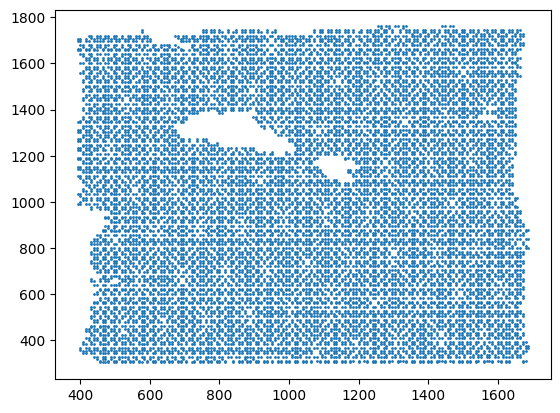

In [68]:
adata_ST1=adata_ST1[location0.index,:]
points2=adata_ST1.obs[['y','x']].to_numpy()
df=adata_ST1.obs[['x','y']]
import matplotlib.pyplot as plt
plt.scatter(df['y'], df['x'], s=1)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def find_nearest_rows_vectorized(points1, points2):
    """
    向量化版本的最近邻搜索，效率更高
    """
    if points1.shape[1] != 2 or points2.shape[1] != 2:
        raise ValueError("两个矩阵都必须是N*2的形状")
    points1_expanded = points1[:, np.newaxis, :]  # 形状: (N, 1, 2)
    points2_expanded = points2[np.newaxis, :, :]  # 形状: (1, M, 2)
    squared_distances = np.sum((points1_expanded - points2_expanded) ** 2, axis=2)  
    nearest_indices = np.argmin(squared_distances, axis=1)
    nearest_distances = np.sqrt(np.min(squared_distances, axis=1))
    return nearest_indices, nearest_distances

nearest_indices, nearest_distances = find_nearest_rows_vectorized(points1, points2)
# 绘制最近距离的分布
plt.figure(figsize=(10, 6))
plt.hist(nearest_distances, bins=200, color='blue', alpha=0.7)
plt.title('Distribution of Nearest Distances')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.xlim(0, 20)
plt.show()

In [72]:
import pandas as pd
mapping_mouse=pd.DataFrame(nearest_indices)
mapping_mouse.columns=['target_index']
mapping_mouse['dist']=nearest_distances
mapping_mouse['ori_index']=[i for i in range(len(nearest_indices))]
location0['index0']=[i for i in range(location0.shape[0])]
merge_df=pd.merge(left=mapping_mouse,right=location0.reset_index(),left_on='target_index',right_on='index0',how='inner')

In [73]:
merge_df=merge_df[merge_df['dist']<6]
merge_df.to_csv('/home/qyyuan/project/ST_GRN/result/Human_Luminal_B_Breast_cancer/mapping_BCAS2.txt',sep='\t')

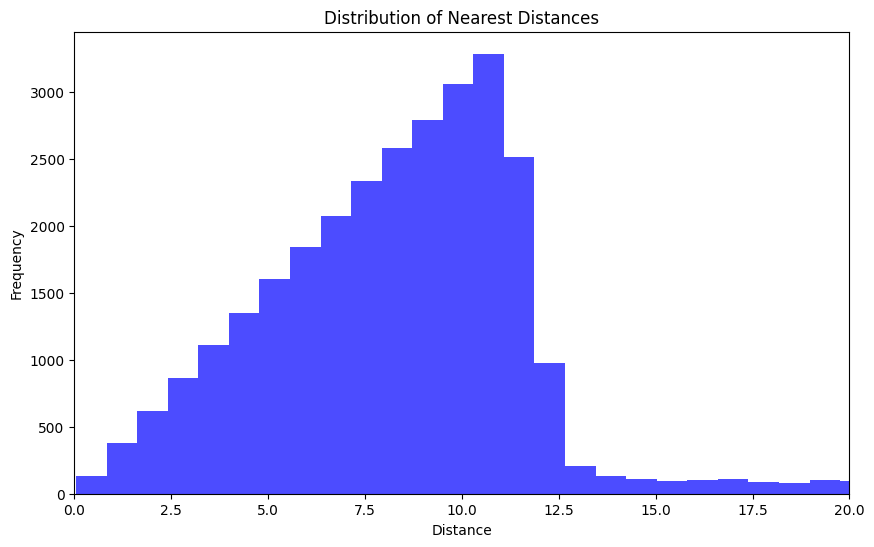

In [ ]:
# 绘制最近距离的分布
nearest_indices1, nearest_distances1 = find_nearest_rows_vectorized(points2, points1)
plt.figure(figsize=(10, 6))
plt.hist(nearest_distances1, bins=300, color='blue', alpha=0.7)
plt.title('Distribution of Nearest Distances')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.xlim(0, 20)
plt.show()

In [13]:
import pandas as pd
mapping_mouse=pd.DataFrame(nearest_indices1)
mapping_mouse.columns=['target_index']
mapping_mouse['dist']=nearest_distances1
mapping_mouse['ori_index']=[i for i in range(len(nearest_indices1))]

In [14]:
mapping_mouse=mapping_mouse[mapping_mouse['dist']<8]
mapping_mouse.to_csv('/home/qyyuan/project/ST_GRN/result/Human_Luminal_B_Breast_cancer/selected_spots_BCAS2.txt')

In [123]:
import scanpy as sc
adata_ST1=sc.read_h5ad('/home/qyyuan/project/ST_GRN/result/Human_Luminal_B_Breast_cancer/enhanced_exp_BCAS2.h5ad')
adata_ST_Ori = sc.read_10x_h5("/home/qyyuan/project/ST_GRN/data/Human_Luminal_B_Breast_cancer/BCAS2/V1_Breast_Cancer_Block_A_Section_2_filtered_feature_bc_matrix.h5")
import pandas as pd
location0=pd.read_csv('/home/qyyuan/project/ST_GRN/result/Human_Luminal_B_Breast_cancer/BCAS2_doman_20.txt',sep='\t',index_col=0)
location=pd.read_csv('/home/qyyuan/project/ST_GRN/data/Human_Luminal_B_Breast_cancer/BCAS2/spatial/tissue_positions_list.csv',sep=',',header=None)
location=location.set_index(0)
location=location.loc[adata_ST_Ori.obs_names]
adata_ST_Ori.obs[['pixel_x',	'pixel_y']]=location[[5,4]]*0.08250825
points1=adata_ST_Ori.obs[['pixel_x','pixel_y']].to_numpy()
df=adata_ST_Ori.obs[['pixel_x','pixel_y']]

/home/qyyuan/.conda/envs/STALocator-zzqyy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/qyyuan/.conda/envs/STALocator-zzqyy/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/qyyuan/.conda/envs/STALocator-zzqyy/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


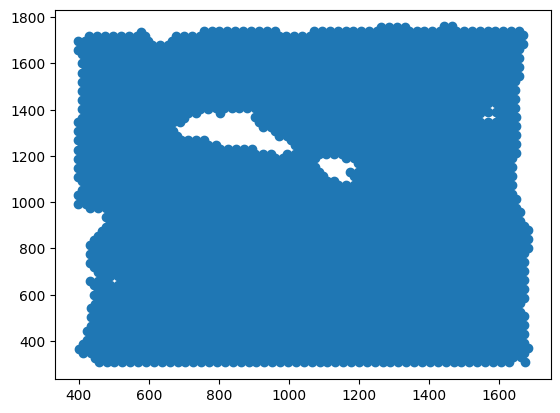

In [124]:
import matplotlib.pyplot as plt
plt.scatter(df['pixel_x'], df['pixel_y'])
plt.show()

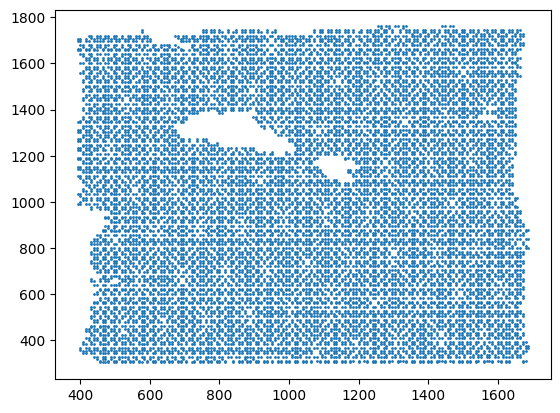

In [125]:
adata_ST1=adata_ST1[location0.index,:]
points2=adata_ST1.obs[['y','x']].to_numpy()
df=adata_ST1.obs[['x','y']]
import matplotlib.pyplot as plt
plt.scatter(df['y'], df['x'], s=1)
plt.show()

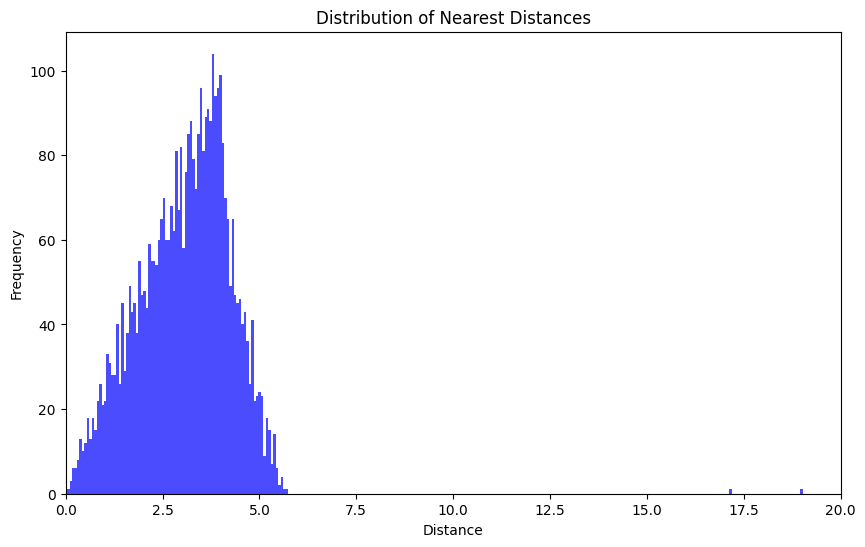

In [128]:
# 绘制最近距离的分布
nearest_indices, nearest_distances = find_nearest_rows_vectorized(points1, points2)
plt.figure(figsize=(10, 6))
plt.hist(nearest_distances, bins=300, color='blue', alpha=0.7)
plt.title('Distribution of Nearest Distances')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.xlim(0, 20)
plt.show()

In [129]:
import pandas as pd
mapping_mouse=pd.DataFrame(nearest_indices)
mapping_mouse.columns=['target_index']
mapping_mouse['dist']=nearest_distances
mapping_mouse['ori_index']=[i for i in range(len(nearest_indices))]
location0['index0']=[i for i in range(location0.shape[0])]
merge_df=pd.merge(left=mapping_mouse,right=location0.reset_index(),left_on='target_index',right_on='index0',how='inner')
merge_df=merge_df[merge_df['dist']<6]
merge_df.index=adata_ST_Ori.obs_names[merge_df['ori_index']]
merge_df.to_csv('/home/qyyuan/project/ST_GRN/result/Human_Luminal_B_Breast_cancer/mapping_BCAS2_v1.txt',sep='\t')

## Human triplenegative breast cancer

In [6]:
import scanpy as sc
adata_ST1=sc.read_h5ad('/home/qyyuan/project/ST_GRN/result/Human_triplenegative_breast_cancer/enhanced_exp_15.h5ad')
#adata_ST_Ori=sc.read('/home/qyyuan/project/ST_GRN/data/mouse_anterior/adata_ST.h5ad')
adata_ST_Ori = sc.read_10x_h5("/home/qyyuan/project/ST_GRN/data/Human_triplenegative_breast_cancer/slice15/GSM6433611_120D_filtered_feature_bc_matrix.h5")
import pandas as pd
#location0=pd.read_csv('/home/qyyuan/project/ST_GRN/result/Human_Luminal_B_Breast_cancer/BCAS1_doman_9.txt',sep='\t',index_col=0)
location=pd.read_csv('/home/qyyuan/project/ST_GRN/data/Human_triplenegative_breast_cancer/slice15/GSM6433611_120D_tissue_positions_list.csv',sep=',',header=None)
location=location.set_index(0)
location=location.loc[adata_ST_Ori.obs_names]
adata_ST_Ori.obs[['pixel_x',	'pixel_y']]=location[[5,4]]*0.083184294
points1=adata_ST_Ori.obs[['pixel_x','pixel_y']].to_numpy()
df=adata_ST_Ori.obs[['pixel_x','pixel_y']]

/home/qyyuan/.conda/envs/STALocator/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/qyyuan/.conda/envs/STALocator/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


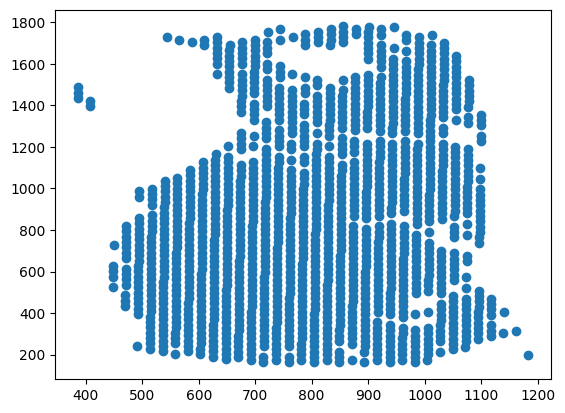

In [7]:
import matplotlib.pyplot as plt
plt.scatter(df['pixel_x'], df['pixel_y'])
plt.show()

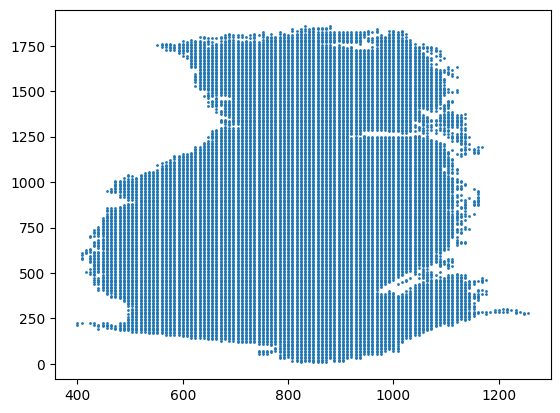

In [8]:
#adata_ST1=adata_ST1[location0.index,:]
points2=adata_ST1.obs[['y','x']].to_numpy()
df=adata_ST1.obs[['x','y']]
import matplotlib.pyplot as plt
plt.scatter(df['y'], df['x'], s=1)
plt.show()

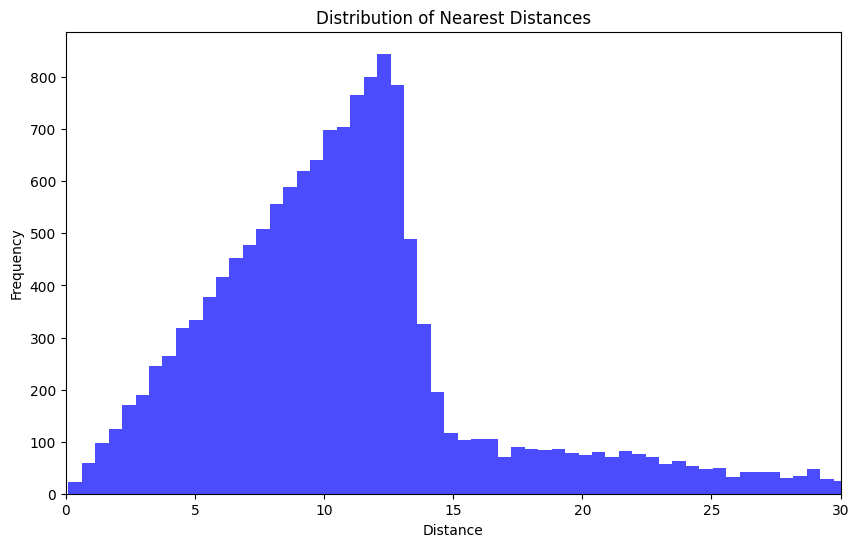

In [16]:
import numpy as np
import matplotlib.pyplot as plt
def find_nearest_rows_vectorized(points1, points2):
    """
    向量化版本的最近邻搜索，效率更高
    """
    if points1.shape[1] != 2 or points2.shape[1] != 2:
        raise ValueError("两个矩阵都必须是N*2的形状")
    points1_expanded = points1[:, np.newaxis, :]  # 形状: (N, 1, 2)
    points2_expanded = points2[np.newaxis, :, :]  # 形状: (1, M, 2)
    squared_distances = np.sum((points1_expanded - points2_expanded) ** 2, axis=2)  
    nearest_indices = np.argmin(squared_distances, axis=1)
    nearest_distances = np.sqrt(np.min(squared_distances, axis=1))
    return nearest_indices, nearest_distances

# 绘制最近距离的分布
nearest_indices1, nearest_distances1 = find_nearest_rows_vectorized(points2, points1)
plt.figure(figsize=(10, 6))
plt.hist(nearest_distances1, bins=300, color='blue', alpha=0.7)
plt.title('Distribution of Nearest Distances')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.xlim(0, 30)
plt.show()

In [17]:
import pandas as pd
mapping_mouse=pd.DataFrame(nearest_indices1)
mapping_mouse.columns=['target_index']
mapping_mouse['dist']=nearest_distances1
mapping_mouse['ori_index']=[i for i in range(len(nearest_indices1))]

In [ ]:
mapping_mouse=mapping_mouse[mapping_mouse['dist']<12]
mapping_mouse.to_csv('/home/qyyuan/project/ST_GRN/result/Human_triplenegative_breast_cancer/selected_spots_15.txt')

## 

## slice 26

In [ ]:
import scanpy as sc
adata_ST1=sc.read_h5ad('/home/qyyuan/project/ST_GRN/result/Human_triplenegative_breast_cancer/enhanced_exp_26.h5ad')
adata_ST_Ori = sc.read_10x_h5("/home/qyyuan/project/ST_GRN/data/Human_triplenegative_breast_cancer/slice26/GSM6433594_094D_filtered_feature_bc_matrix.h5")
import pandas as pd
location=pd.read_csv('/home/qyyuan/project/ST_GRN/data/Human_triplenegative_breast_cancer/slice26/GSM6433594_094D_tissue_positions_list.csv',sep=',',header=None)
location=location.set_index(0)
location=location.loc[adata_ST_Ori.obs_names]
adata_ST_Ori.obs[['pixel_x',	'pixel_y']]=location[[5,4]]*0.0954335
points1=adata_ST_Ori.obs[['pixel_x','pixel_y']].to_numpy()
df=adata_ST_Ori.obs[['pixel_x','pixel_y']]

/home/qyyuan/.conda/envs/STALocator/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/qyyuan/.conda/envs/STALocator/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


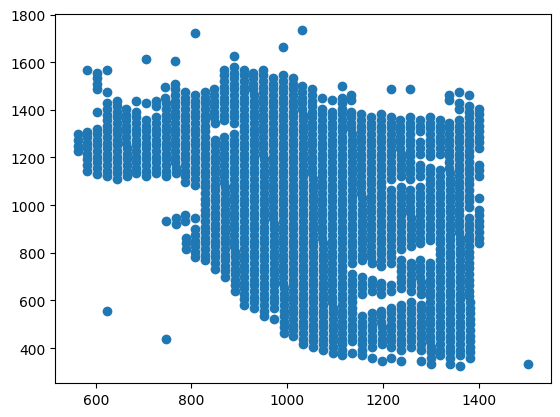

In [34]:
import matplotlib.pyplot as plt
plt.scatter(df['pixel_x'], df['pixel_y'])
plt.show()

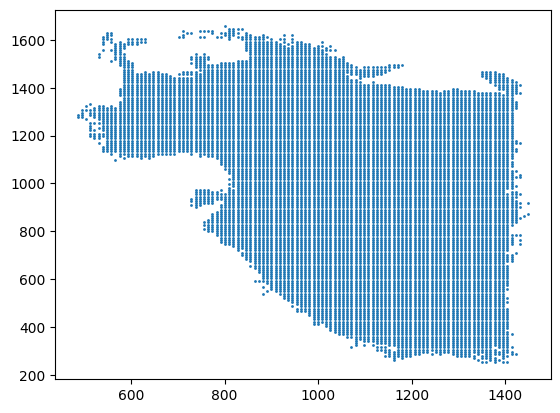

In [35]:
#adata_ST1=adata_ST1[location0.index,:]
points2=adata_ST1.obs[['y','x']].to_numpy()
df=adata_ST1.obs[['x','y']]
import matplotlib.pyplot as plt
plt.scatter(df['y'], df['x'], s=1)
plt.show()

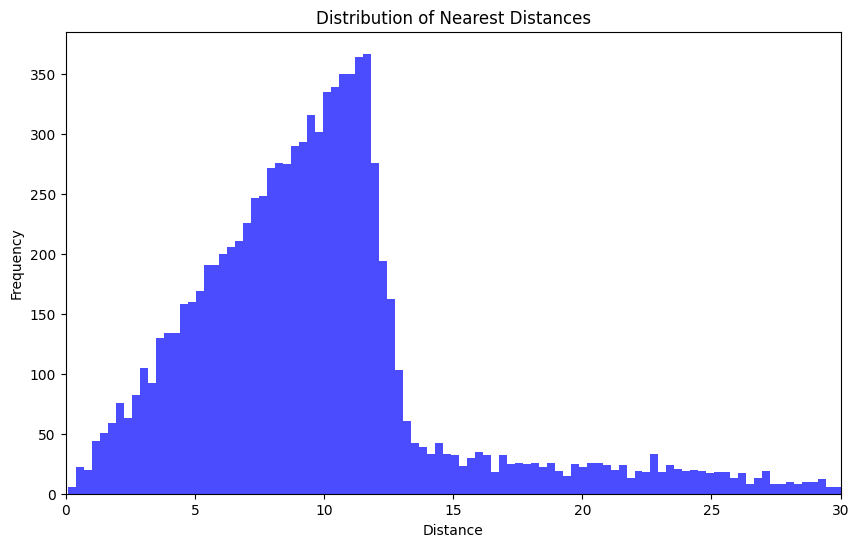

In [37]:
import numpy as np
import matplotlib.pyplot as plt
def find_nearest_rows_vectorized(points1, points2):
    """
    向量化版本的最近邻搜索，效率更高
    """
    if points1.shape[1] != 2 or points2.shape[1] != 2:
        raise ValueError("两个矩阵都必须是N*2的形状")
    points1_expanded = points1[:, np.newaxis, :]  # 形状: (N, 1, 2)
    points2_expanded = points2[np.newaxis, :, :]  # 形状: (1, M, 2)
    squared_distances = np.sum((points1_expanded - points2_expanded) ** 2, axis=2)  
    nearest_indices = np.argmin(squared_distances, axis=1)
    nearest_distances = np.sqrt(np.min(squared_distances, axis=1))
    return nearest_indices, nearest_distances

# 绘制最近距离的分布
nearest_indices1, nearest_distances1 = find_nearest_rows_vectorized(points2, points1)
plt.figure(figsize=(10, 6))
plt.hist(nearest_distances1, bins=300, color='blue', alpha=0.7)
plt.title('Distribution of Nearest Distances')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.xlim(0, 30)
plt.show()

In [38]:
import pandas as pd
mapping_mouse=pd.DataFrame(nearest_indices1)
mapping_mouse.columns=['target_index']
mapping_mouse['dist']=nearest_distances1
mapping_mouse['ori_index']=[i for i in range(len(nearest_indices1))]

In [ ]:
mapping_mouse=mapping_mouse[mapping_mouse['dist']<12]
mapping_mouse.to_csv('/home/qyyuan/project/ST_GRN/result/Human_triplenegative_breast_cancer/selected_spots_26.txt')

/home/qyyuan/.conda/envs/STALocator-zzqyy/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/qyyuan/.conda/envs/STALocator-zzqyy/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/qyyuan/.conda/envs/STALocator-zzqyy/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


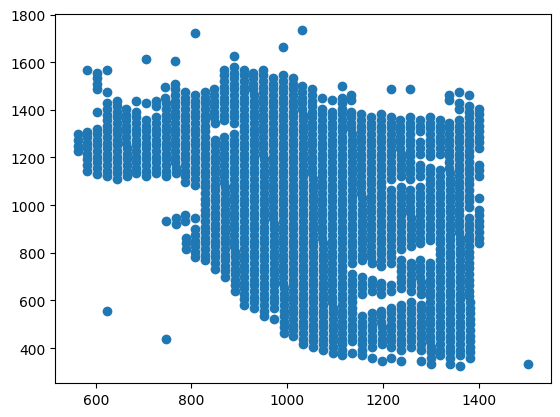

In [99]:
import scanpy as sc
adata_ST1=sc.read_h5ad('/home/qyyuan/project/ST_GRN/result/Human_triplenegative_breast_cancer/enhanced_exp_26.h5ad')
adata_ST_Ori = sc.read_10x_h5("/home/qyyuan/project/ST_GRN/data/Human_triplenegative_breast_cancer/slice26/GSM6433594_094D_filtered_feature_bc_matrix.h5")
import pandas as pd
location=pd.read_csv('/home/qyyuan/project/ST_GRN/data/Human_triplenegative_breast_cancer/slice26/GSM6433594_094D_tissue_positions_list.csv',sep=',',header=None)
location=location.set_index(0)
location=location.loc[adata_ST_Ori.obs_names]
adata_ST_Ori.obs[['pixel_x',	'pixel_y']]=location[[5,4]]*0.0954335
points1=adata_ST_Ori.obs[['pixel_x','pixel_y']].to_numpy()
df=adata_ST_Ori.obs[['pixel_x','pixel_y']]
import matplotlib.pyplot as plt
plt.scatter(df['pixel_x'], df['pixel_y'])
plt.show()

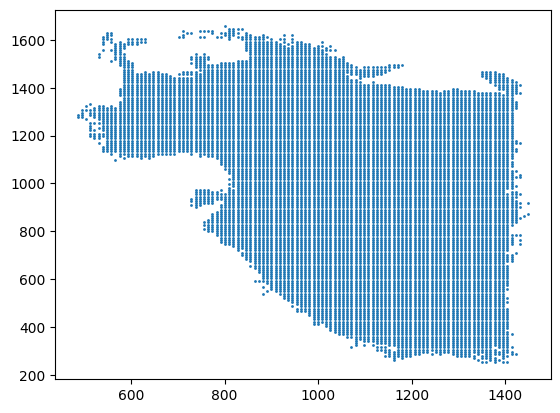

In [100]:
adata_ST1=adata_ST1[location0.index,:]
points2=adata_ST1.obs[['y','x']].to_numpy()
df=adata_ST1.obs[['x','y']]
import matplotlib.pyplot as plt
plt.scatter(df['y'], df['x'], s=1)
plt.show()

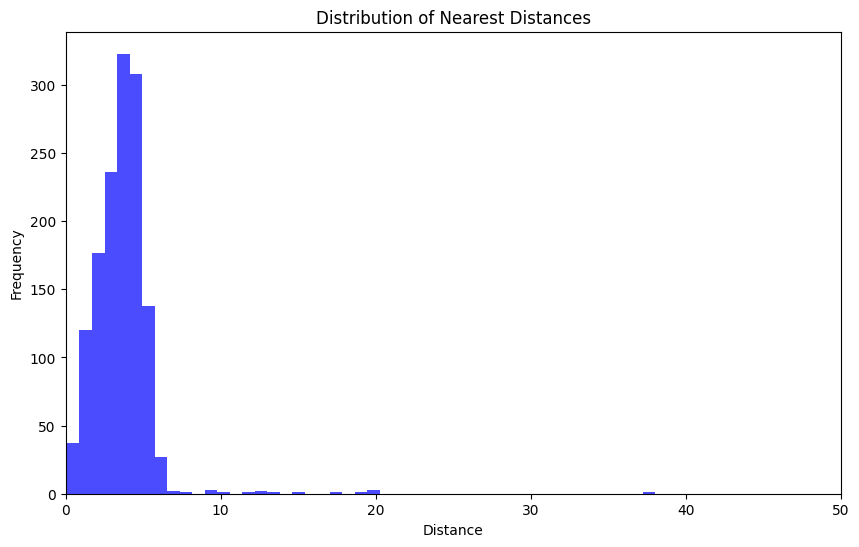

In [105]:
import numpy as np
import matplotlib.pyplot as plt
def find_nearest_rows_vectorized(points1, points2):
    """
    向量化版本的最近邻搜索，效率更高
    """
    if points1.shape[1] != 2 or points2.shape[1] != 2:
        raise ValueError("两个矩阵都必须是N*2的形状")
    points1_expanded = points1[:, np.newaxis, :]  # 形状: (N, 1, 2)
    points2_expanded = points2[np.newaxis, :, :]  # 形状: (1, M, 2)
    squared_distances = np.sum((points1_expanded - points2_expanded) ** 2, axis=2)  
    nearest_indices = np.argmin(squared_distances, axis=1)
    nearest_distances = np.sqrt(np.min(squared_distances, axis=1))
    return nearest_indices, nearest_distances

nearest_indices, nearest_distances = find_nearest_rows_vectorized(points1, points2)
# 绘制最近距离的分布
plt.figure(figsize=(10, 6))
plt.hist(nearest_distances, bins=300, color='blue', alpha=0.7)
plt.title('Distribution of Nearest Distances')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.xlim(0, 50)
plt.show()

In [106]:
import pandas as pd
mapping_mouse=pd.DataFrame(nearest_indices)
mapping_mouse.columns=['target_index']
mapping_mouse['dist']=nearest_distances
mapping_mouse['ori_index']=[i for i in range(len(nearest_indices))]

In [108]:
mapping_mouse=mapping_mouse[mapping_mouse['dist']<8]

,target_index,dist,ori_index
0,1217,5.295554,0
1,379,4.006220,1
2,8726,1.960384,2
3,7015,2.236410,3
4,9393,2.827781,4
...,...,...,...
1386,4935,2.476180,1386
1387,5062,4.788415,1387
1388,6947,3.727219,1388
1389,3282,2.992028,1389


In [113]:

location0=pd.read_csv('/home/qyyuan/project/ST_GRN/result/Human_triplenegative_breast_cancer/26_doman_12.txt',sep='\t',index_col=0)

In [114]:
location0

,x,y,color,z,CD151,x_array,y_array,x_pixel,y_pixel,n_counts,pred,refined_pred
0,252,1350,226.883105,672.155256,2.066274,252,1350,252,1350,9164.414433,11,11
1,252,1359,226.720051,670.024987,1.964468,252,1359,252,1359,9156.323851,7,7
2,252,1377,220.291155,586.032589,2.175166,252,1377,252,1377,9635.055240,7,7
3,252,1395,226.816303,671.282493,2.214108,252,1395,252,1395,9407.561437,7,7
4,252,1404,226.082766,661.698960,2.172738,252,1404,252,1404,9482.391382,7,7
...,...,...,...,...,...,...,...,...,...,...,...,...
9686,1647,810,224.505635,641.094025,1.966728,1647,810,1647,810,9473.100601,2,2
9687,1647,819,226.276112,664.224997,1.966479,1647,819,1647,819,9470.006663,2,2
9688,1647,828,226.336079,665.008456,1.936101,1647,828,1647,828,9473.237902,2,2
9689,1647,837,226.565955,668.011742,1.883347,1647,837,1647,837,8935.483717,2,2


In [120]:
mapping_mouse[['pred','refined_pred']]=location0.loc[mapping_mouse['target_index'].values,['pred','refined_pred']].values

/tmp/ipykernel_2266793/1852462094.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mapping_mouse[['pred','refined_pred']]=location0.loc[mapping_mouse['target_index'].values,['pred','refined_pred']].values


In [121]:
mapping_mouse

,target_index,dist,ori_index,pred,refined_pred
0,1217,5.295554,0,6,6
1,379,4.006220,1,6,6
2,8726,1.960384,2,8,8
3,7015,2.236410,3,1,1
4,9393,2.827781,4,8,8
...,...,...,...,...,...
1386,4935,2.476180,1386,0,0
1387,5062,4.788415,1387,0,0
1388,6947,3.727219,1388,2,2
1389,3282,2.992028,1389,5,5


In [122]:
mapping_mouse.to_csv('/home/qyyuan/project/ST_GRN/result/Human_triplenegative_breast_cancer/mapping_26.txt',sep='\t')